In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error,mean_absolute_error
import yfinance as yf
import seaborn as sns

In [2]:
df = yf.download("AAPL", start = "2015-01-01", end= "2026-04-09")
df.to_csv("AAPL.csv")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214899,24.682231,23.776359,24.671157,212818400
2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400
2026-04-02,255.919998,256.130005,250.649994,254.199997,31289400
2026-04-06,258.859985,262.160004,256.459991,256.510010,29329900
2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800


In [5]:
df.shape

(2832, 5)

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2832.000000,2832.000000,2832.000000,2832.000000,2.832000e+03
mean,109.806183,110.903418,108.612256,109.718279,1.099094e+08
std,76.967196,77.720095,76.154356,76.909880,6.797401e+07
min,20.584822,20.887866,20.386585,20.507342,1.791060e+07
25%,37.097624,37.428632,36.689746,37.080095,6.311622e+07
50%,107.174049,109.047816,105.552703,107.231072,9.310420e+07
75%,171.083969,172.144461,169.009012,170.646430,1.357272e+08
max,285.922455,288.350192,283.035157,285.932471,6.488252e+08


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2832 entries, 2015-01-02 to 2026-04-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2832 non-null   float64
 1   (High, AAPL)    2832 non-null   float64
 2   (Low, AAPL)     2832 non-null   float64
 3   (Open, AAPL)    2832 non-null   float64
 4   (Volume, AAPL)  2832 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 132.8 KB


In [8]:
df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30',
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06',
               '2026-04-07', '2026-04-08'],
              dtype='datetime64[s]', name='Date', length=2832, freq=None)

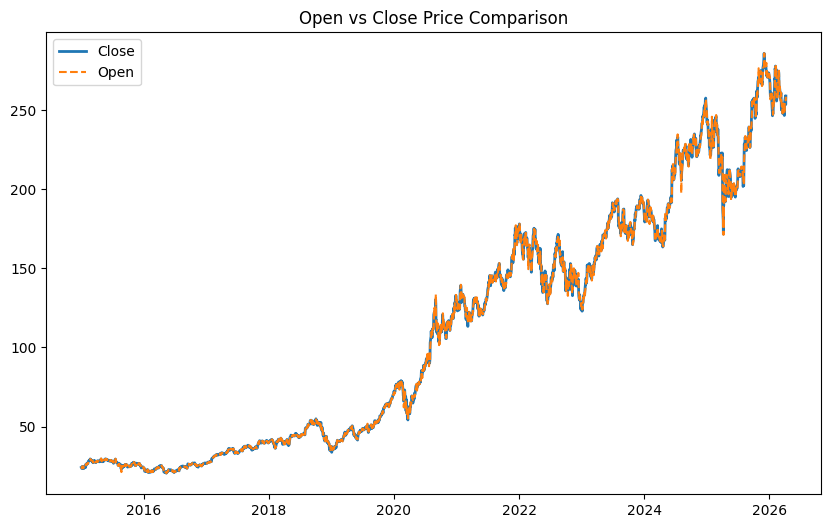

In [9]:
plt.figure(figsize=(10,6))

plt.plot(df.index, df["Close"], label="Close", linewidth=2)
plt.plot(df.index, df["Open"], label="Open", linestyle='--')

plt.legend()
plt.title("Open vs Close Price Comparison")
plt.show()

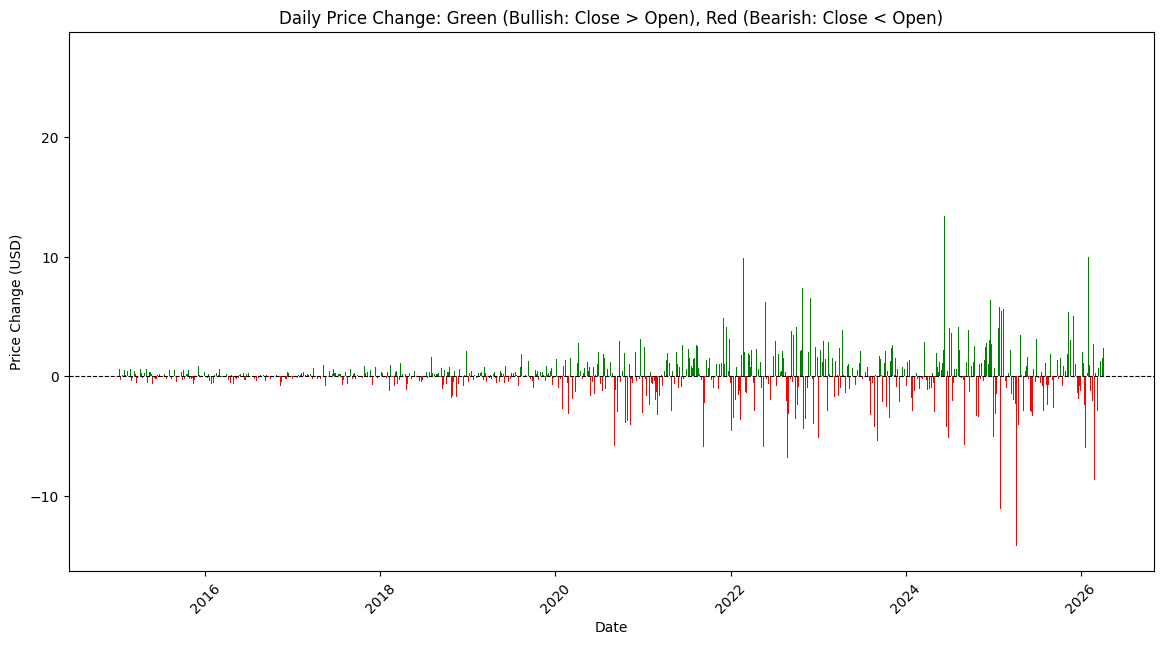

In [10]:
# Calculate the daily price difference
df['Diff'] = df['Close'] - df['Open']

# Assign colors: green for bullish (Diff > 0), red for bearish (Diff < 0)
colors = ['green' if x > 0 else 'red' for x in df['Diff']]

# Create the bar plot
plt.figure(figsize=(14, 7))  # Adjust figsize for better visibility with many data points
plt.bar(df.index, df['Diff'], color=colors, width=1)  # width=1 for daily bars; adjust if needed

# Add labels and title
plt.title('Daily Price Change: Green (Bullish: Close > Open), Red (Bearish: Close < Open)')
plt.xlabel('Date')
plt.ylabel('Price Change (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Horizontal line at zero for reference

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.show()

In [11]:
df["MA_5"]=df["Close"].rolling(window=5).mean()
df["MA_20"]=df["Close"].rolling(window=20).mean()
df["MA_60"]=df["Close"].rolling(window=60).mean()

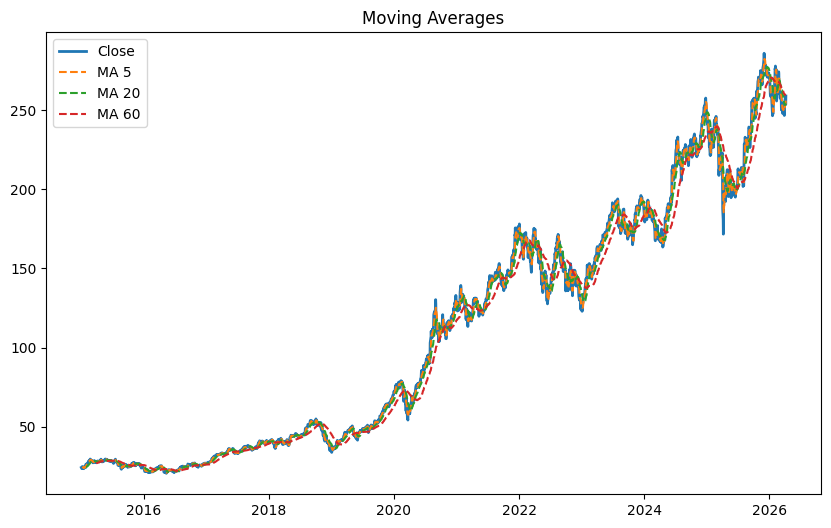

In [12]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["Close"], label="Close", linewidth=2)
plt.plot(df.index, df["MA_5"], label="MA 5", linestyle='--')
plt.plot(df.index, df["MA_20"], label="MA 20", linestyle='--')
plt.plot(df.index, df["MA_60"], label="MA 60", linestyle='--')
plt.legend()
plt.title("Moving Averages")
plt.show()

In [13]:
df["Month"] = df.index.month
df["Year"] = df.index.year

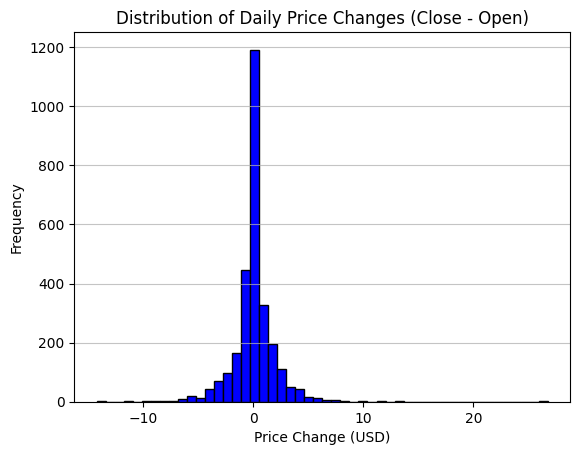

In [14]:
df['Diff'].plot(kind='hist', bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Daily Price Changes (Close - Open)')
plt.xlabel('Price Change (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

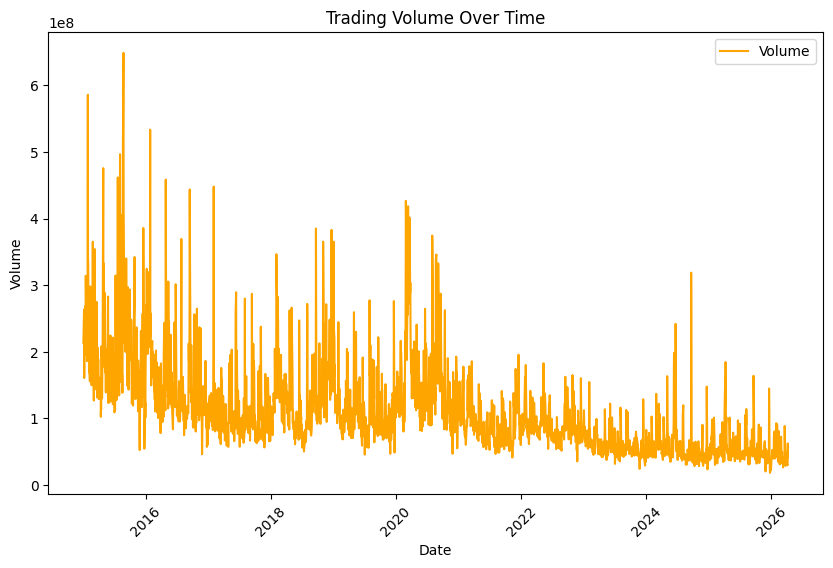

In [15]:
plt.figure(figsize=(10,6))
plt.plot(df.index,df["Volume"], label="Volume", color='orange')
plt.legend()
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()  

In [16]:
df["Vol_5"]=df["Volume"].rolling(window=5).mean()
df["Vol_20"]=df["Volume"].rolling(window=20).mean()
df["Vol_60"]=df["Volume"].rolling(window=60).mean()

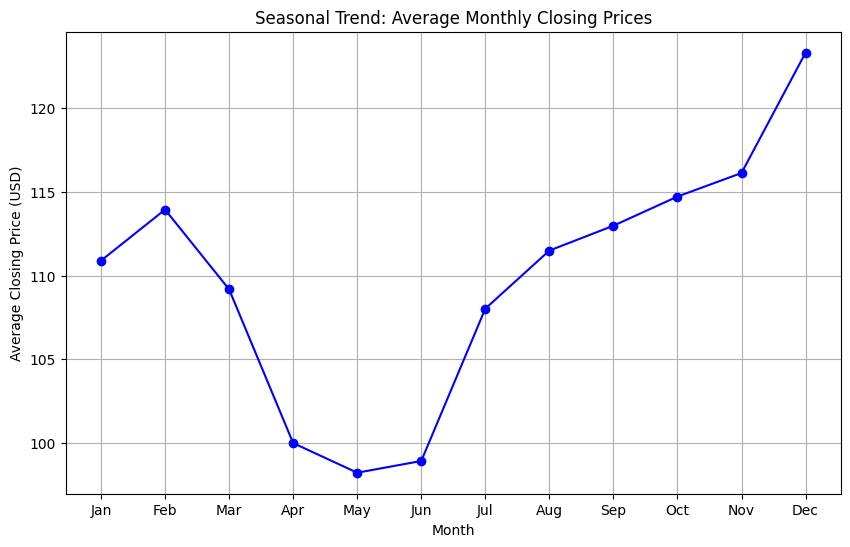

In [17]:
# Calculate monthly average closing prices
monthly_avg = df.groupby('Month')['Close'].mean()

# Plot the seasonal trend
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='blue')
plt.title('Seasonal Trend: Average Monthly Closing Prices')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (USD)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

In [18]:
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfWeek'] = df.index.dayofweek

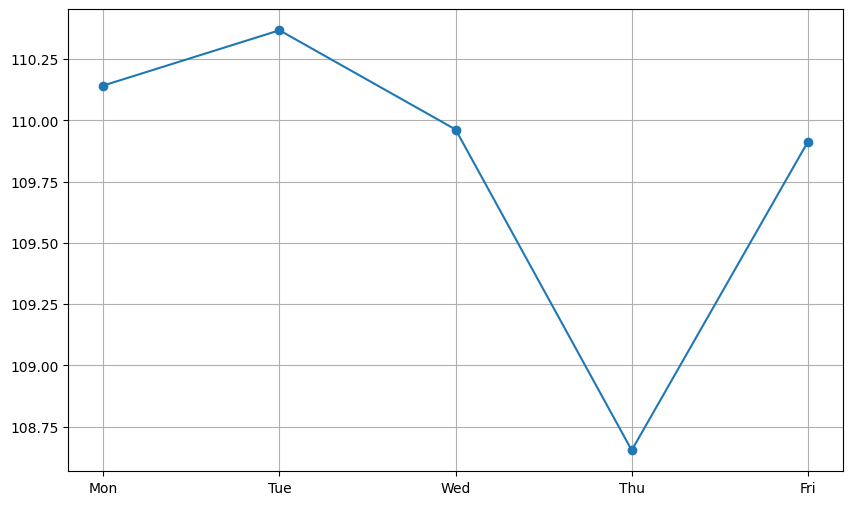

In [21]:
# Calculate monthly average closing prices
weekly_avg = df.groupby('DayOfWeek')['Close'].mean()

day_map = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

plt.figure(figsize=(10, 6))
plt.plot(weekly_avg.index, weekly_avg.values, marker='o')

plt.xticks(weekly_avg.index, [day_map[i] for i in weekly_avg.index])
plt.grid(True)
plt.show()

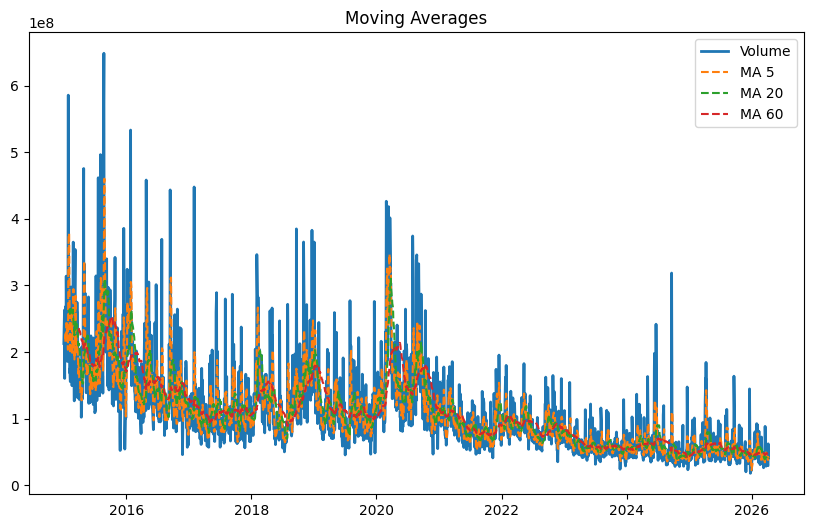

In [25]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["Volume"], label="Volume", linewidth=2)
plt.plot(df.index, df["Vol_5"], label="MA 5", linestyle='--')
plt.plot(df.index, df["Vol_20"], label="MA 20", linestyle='--')
plt.plot(df.index, df["Vol_60"], label="MA 60", linestyle='--')
plt.legend()
plt.title("Moving Averages")
plt.show()